In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("All imports successful")

All imports successful


In [2]:
# Load Data
df = pd.read_csv("data/Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Check Shape: Shows dimensions of the data: (200, 5) means 200 customers and 5 columns.
df.shape


(200, 5)

In [4]:
# Gives a summary of the dataset
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.isnull().sum()



CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
#  Clean Column Names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)


In [7]:
df.head()


,customerid,gender,age,annual_income_k$,spending_score_1-100
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
df.describe()


,customerid,age,annual_income_k$,spending_score_1-100
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
df.columns = ['customer_id', 'gender', 'age', 'annual_income', 'spending_score']


In [10]:
df.columns


Index(['customer_id', 'gender', 'age', 'annual_income', 'spending_score'], dtype='object')

In [11]:
df.describe()


,customer_id,age,annual_income,spending_score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [12]:
# select columns to cluster on
X = df[['annual_income', 'spending_score']]

In [13]:
# segmentation based on income: Two customers are similar if they behave similarly
# next, we scale: Putting all variables on the same ruler

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 
# This is important because income values are much larger than spending scores, and we don't want one to dominate the clustering.

In [15]:
#Elbow method: Tests different numbers of clusters (1-10) and calculates the "within-cluster sum of squares" for each. 
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


# This helps figure out the optimal number of clusters by looking for an "elbow" in the plot.

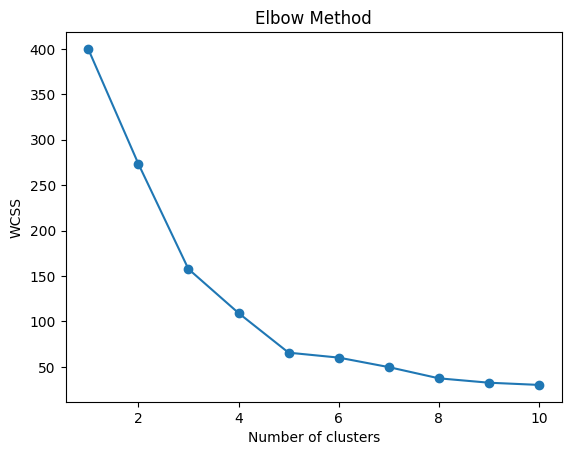

In [16]:


plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# Creates a line chart of the elbow method results. Where the line starts to flatten out is usually the best number of clusters.

In [17]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)
# Runs K-Means with 5 clusters and assigns each customer to a cluster (0-4) the adds it as a new column to my dataframe.

In [18]:
df.head()


,customer_id,gender,age,annual_income,spending_score,cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [19]:
df.groupby('cluster')[['annual_income', 'spending_score']].mean()


,annual_income,spending_score
cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [20]:
cluster_labels = {
    0: 'Low Income - Low Spending',
    1: 'High Income - High Spending (VIP)',
    2: 'Low Income - High Spending',
    3: 'High Income - Low Spending (At Risk)',
    4: 'Average Customers'
}

df['segment'] = df['cluster'].map(cluster_labels)


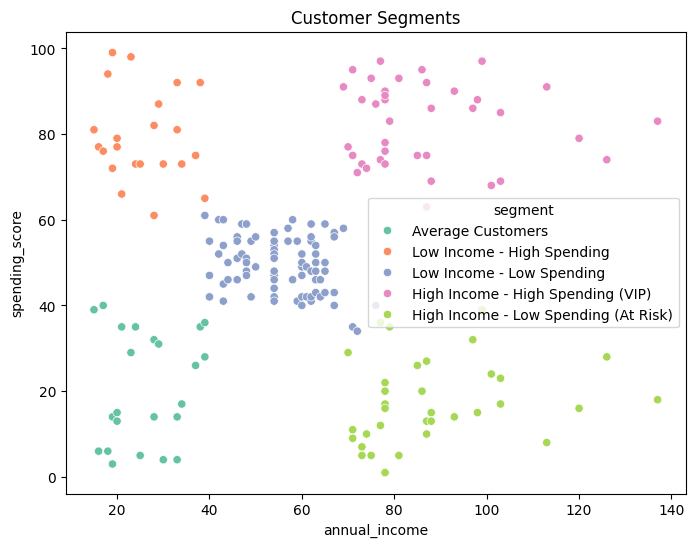

In [21]:


plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='annual_income',
    y='spending_score',
    hue='segment',
    palette='Set2'
)
plt.title('Customer Segments')
plt.show()

# Creates a scatter plot showing customers colored by their segment

In [22]:
# Group by cluster and calculate averages (income and spending)
cluster_summary = df.groupby('cluster')[['annual_income', 'spending_score']].mean().round(2)
print(cluster_summary)


         annual_income  spending_score
cluster                               
0                55.30           49.52
1                86.54           82.13
2                25.73           79.36
3                88.20           17.11
4                26.30           20.91


In [23]:
df['cluster'].value_counts()
# how many customers are in each of the 5 clusters

cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

In [24]:
df[['customer_id', 'annual_income', 'spending_score', 'cluster', 'segment']].head()
# display

,customer_id,annual_income,spending_score,cluster,segment
0,1,15,39,4,Average Customers
1,2,15,81,2,Low Income - High Spending
2,3,16,6,4,Average Customers
3,4,16,77,2,Low Income - High Spending
4,5,17,40,4,Average Customers


In [25]:
df.groupby('segment')[['annual_income', 'spending_score']].agg(['mean', 'min', 'max', 'count'])
# For each segment, calculates mean, minimum, maximum, and count of customers for both income and spending score

annual_income                 \
                                              mean min  max count   
segment                                                             
Average Customers                        26.304348  15   39    23   
High Income - High Spending (VIP)        86.538462  69  137    39   
High Income - Low Spending (At Risk)     88.200000  70  137    35   
Low Income - High Spending               25.727273  15   39    22   
Low Income - Low Spending                55.296296  39   76    81   

                                     spending_score                
                                               mean min max count  
segment                                                            
Average Customers                         20.913043   3  40    23  
High Income - High Spending (VIP)         82.128205  63  97    39  
High Income - Low Spending (At Risk)      17.114286   1  39    35  
Low Income - High Spending                79.363636  61  99    22  
Low Income - Low Spending                 49.518519  34  61    81

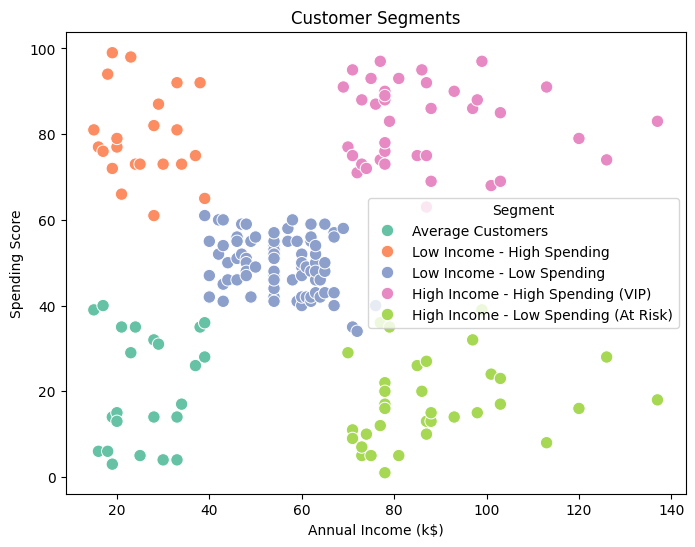

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='annual_income',
    y='spending_score',
    hue='segment',
    palette='Set2',
    s=80
)
plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend(title='Segment')
plt.show()

# Creates an improved scatter plot with proper axis labels, title, and legend showing all 5 customer segments in different colors.

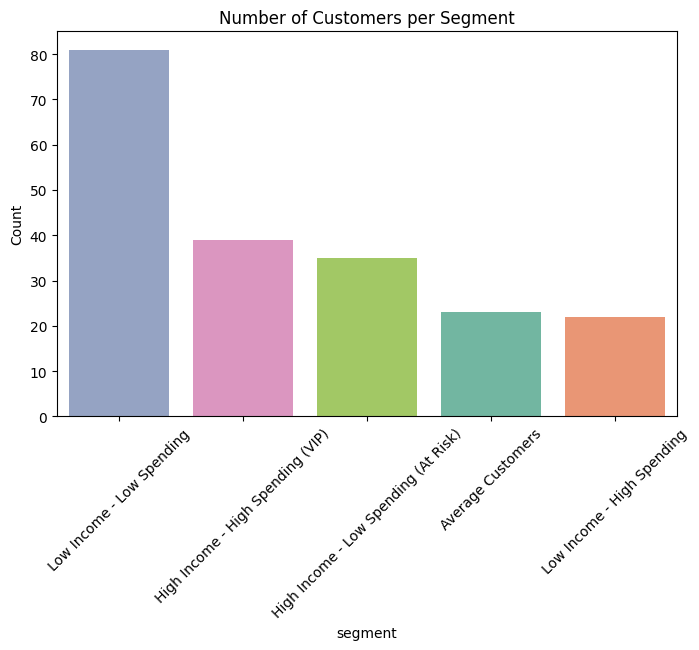

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='segment', hue='segment', order=df['segment'].value_counts().index, palette='Set2', legend=False)
plt.xticks(rotation=45)
plt.title('Number of Customers per Segment')
plt.ylabel('Count')
plt.show()

# Creates a bar chart showing how many customers are in each segment, ordered from most to least customers, with rotated labels for readability.

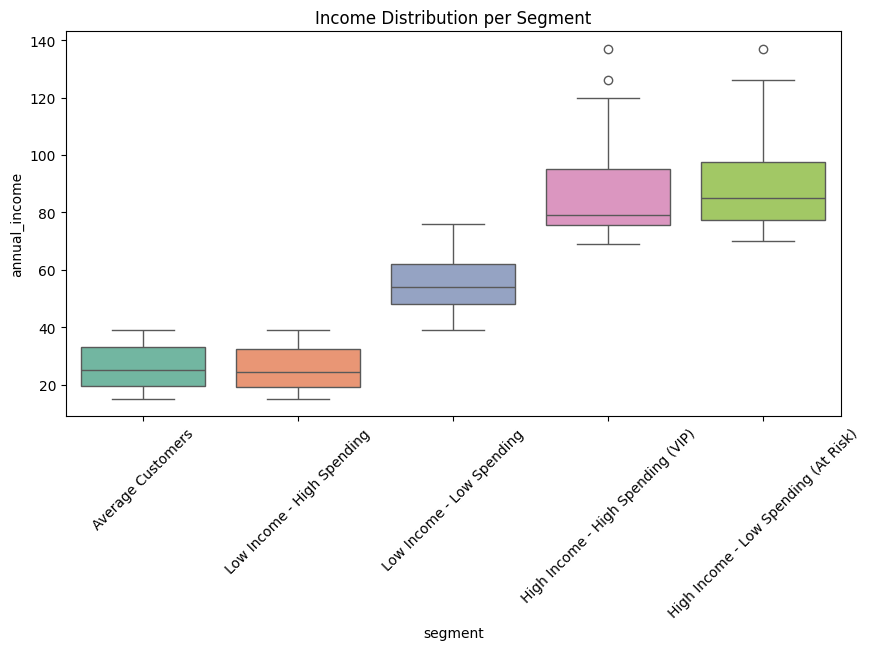

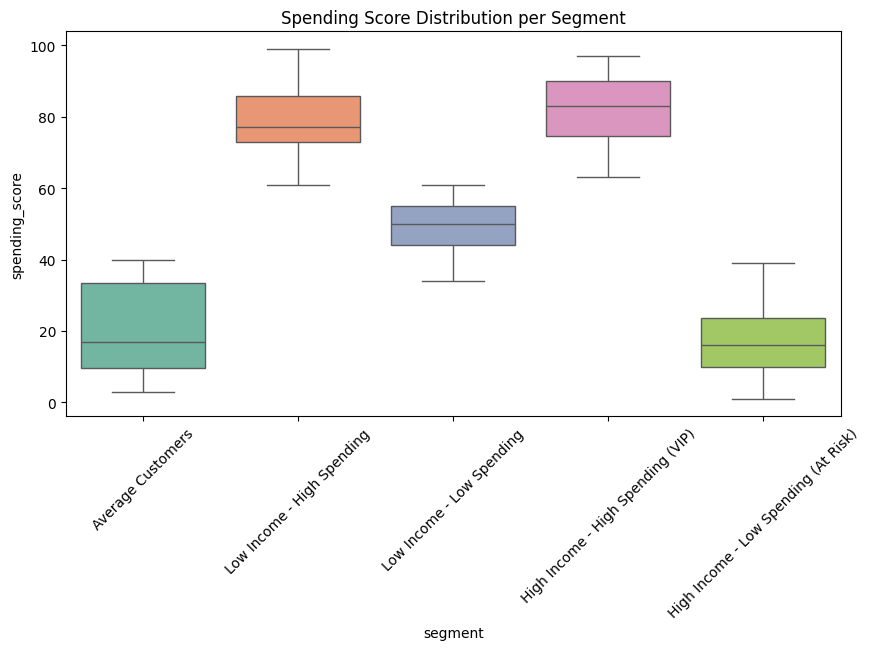

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(x='segment', y='annual_income', hue='segment', data=df, palette='Set2', legend=False)
plt.xticks(rotation=45)
plt.title('Income Distribution per Segment')
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='segment', y='spending_score', hue='segment', data=df, palette='Set2', legend=False)
plt.xticks(rotation=45)
plt.title('Spending Score Distribution per Segment')
plt.show()

# Creates two box plots showing the distribution (median, quartiles, outliers) of income and spending score for each segment. 
#This helps visualize the spread and range of values within each customer segment.